## Jay Sanjaykumar Beladiya
### Group 3 DATA 6550
#### Group Project 4


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Section 1: Data Exploration

In [3]:
FILE_PATH = "data/mortgage_covenant_data.csv"   # change path if needed

df = pd.read_csv(FILE_PATH)

In [4]:
print("Shape:", df.shape)

Shape: (100931, 14)


In [5]:
print(df.columns.tolist())

['activity_year', 'census_tract', 'derived_race', 'action_taken', 'loan_amount', 'property_value', 'income', 'interest_rate', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'denial_reason-1', 'covenant_count', 'was_approved', 'covenant_density']


In [6]:
print(df.head())

   activity_year  census_tract        derived_race  action_taken  loan_amount  \
0           2023  2.703706e+10  Race Not Available             6     185000.0   
1           2023  2.714103e+10  Race Not Available             6     375000.0   
2           2023  2.702395e+10  Race Not Available             6     105000.0   
3           2023  2.717110e+10  Race Not Available             6     285000.0   
4           2023  2.715948e+10  Race Not Available             6     175000.0   

   property_value  income  interest_rate  tract_minority_population_percent  \
0        195000.0     NaN          6.125                              40.37   
1        385000.0     NaN          6.625                              10.64   
2        105000.0     NaN          6.125                               8.92   
3        285000.0     NaN          6.750                              13.27   
4        175000.0     NaN          6.875                               5.87   

   tract_to_msa_income_percentage  den

In [7]:
# Standardize column names
df.columns = [c.strip().replace(" ", "_").replace("-", "_") for c in df.columns]

# Convert was_approved to integer
if df["was_approved"].dtype != "int64" and df["was_approved"].dtype != "float64":
    df["was_approved"] = df["was_approved"].astype(str).str.lower().map({
        "true": 1, "false": 0
    })


In [8]:
# Numeric conversions
numeric_cols = [
    "loan_amount",
    "property_value",
    "income",
    "interest_rate",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [9]:
# Clean categorical columns
df["derived_race"] = df["derived_race"].fillna("Unknown").astype(str).str.strip()
df["covenant_density"] = df["covenant_density"].fillna("No Recorded Covenant").astype(str).str.strip()

In [10]:
# Keep only positive numeric values where applicable
for col in ["loan_amount", "property_value", "income", "interest_rate"]:
    df.loc[df[col] <= 0, col] = np.nan

In [ ]:
# Check for missing values
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)


interest_rate                        24.113503
property_value                       17.279131
income                               12.866216
census_tract                          1.006628
activity_year                         0.000000
derived_race                          0.000000
action_taken                          0.000000
loan_amount                           0.000000
tract_minority_population_percent     0.000000
tract_to_msa_income_percentage        0.000000
denial_reason_1                       0.000000
covenant_count                        0.000000
was_approved                          0.000000
covenant_density                      0.000000
dtype: float64


In [13]:
df["historically_covenanted"] = np.where(df["covenant_count"] > 0, 1, 0)

# Create grouped covenant count bands
def covenant_band(x):
    if pd.isna(x):
        return "Unknown"
    elif x == 0:
        return "None"
    elif x <= 10:
        return "1-10"
    elif x <= 50:
        return "11-50"
    elif x <= 100:
        return "51-100"
    else:
        return "100+"

df["covenant_count_band"] = df["covenant_count"].apply(covenant_band)


In [14]:
# Minority population groups
df["minority_pct_band"] = pd.cut(
    df["tract_minority_population_percent"],
    bins=[0, 25, 50, 75, 100],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

In [15]:
# Income relative to metro groups
df["tract_income_band"] = pd.cut(
    df["tract_to_msa_income_percentage"],
    bins=[0, 80, 120, np.inf],
    labels=["Below MSA (<80)", "Middle MSA (80-120)", "Above MSA (>120)"],
    include_lowest=True
)

In [17]:
print("DESCRIPTIVE STATISTICS")
print(df[numeric_cols + ["was_approved"]].describe())

print("\nApproval Rate Overall:")
print(df["was_approved"].mean())

print("\nCovenant Density Distribution:")
print(df["covenant_density"].value_counts(dropna=False))

DESCRIPTIVE STATISTICS
        loan_amount  property_value        income  interest_rate  \
count  1.009310e+05    8.349100e+04  8.794500e+04   76593.000000   
mean   3.110060e+05    3.987726e+05  1.498266e+02       6.706598   
std    7.617088e+05    1.197102e+06  5.575683e+03       0.878101   
min    5.000000e+03    5.000000e+03  1.000000e+00       0.045900   
25%    1.750000e+05    2.350000e+05  6.700000e+01       6.250000   
50%    2.650000e+05    3.250000e+05  9.600000e+01       6.750000   
75%    3.650000e+05    4.350000e+05  1.460000e+02       7.125000   
max    5.700500e+07    1.113250e+08  1.651000e+06      15.500000   

       tract_minority_population_percent  tract_to_msa_income_percentage  \
count                      100931.000000                   100931.000000   
mean                           22.874029                      101.813583   
std                            17.292952                       32.381060   
min                             0.000000                    

### Section 2: Data Bias Analysis 

In [18]:
# Property values by historical covenant status
property_by_covenant = (
    df.groupby("historically_covenanted")["property_value"]
    .agg(["count", "mean", "median", "std"])
)
print("\nProperty Value by Historical Covenant Status:")
print(property_by_covenant)


Property Value by Historical Covenant Status:
                         count           mean    median           std
historically_covenanted                                              
0                        74110  387560.383214  315000.0  1.217206e+06
1                         9381  487349.429698  355000.0  1.020242e+06


In [19]:
# Property values by covenant_count_band
property_by_band = (
    df.groupby("covenant_count_band")["property_value"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
print("\nProperty Value by Covenant Count Band:")
print(property_by_band)


Property Value by Covenant Count Band:
                     count           mean    median           std
covenant_count_band                                              
1-10                  2354  411588.785047  325000.0  3.188867e+05
100+                  4098  521232.308443  385000.0  1.108950e+06
11-50                 1425  430796.491228  335000.0  3.732720e+05
51-100                1504  567187.500000  365000.0  1.682592e+06
None                 74110  387560.383214  315000.0  1.217206e+06


In [20]:
# Neighborhood characteristics by covenant status
neighborhood_by_covenant = (
    df.groupby("historically_covenanted")[[
        "tract_minority_population_percent",
        "tract_to_msa_income_percentage",
        "income"
    ]]
    .mean()
)
print("\nNeighborhood Characteristics by Historical Covenant Status:")
print(neighborhood_by_covenant)


Neighborhood Characteristics by Historical Covenant Status:
                         tract_minority_population_percent  \
historically_covenanted                                      
0                                                21.940751   
1                                                30.374508   

                         tract_to_msa_income_percentage      income  
historically_covenanted                                              
0                                            100.679432  147.689739  
1                                            110.928425  167.243159  


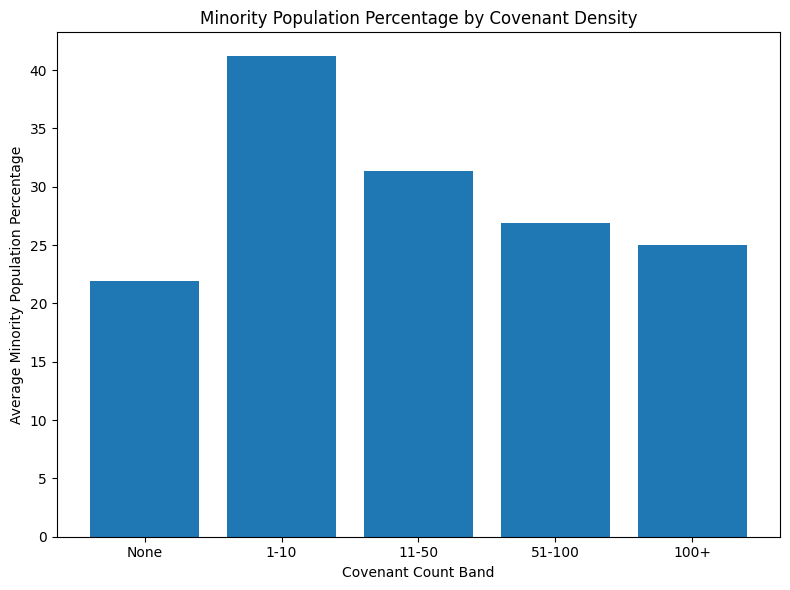

In [27]:
import matplotlib.pyplot as plt

band_order = ["None", "1-10", "11-50", "51-100", "100+"]
minority_density = df.groupby("covenant_count_band")["tract_minority_population_percent"].mean()
minority_density = minority_density.reindex(band_order)

plt.figure(figsize=(8, 6))
plt.bar(minority_density.index, minority_density.values)

plt.title("Minority Population Percentage by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Minority Population Percentage")

plt.tight_layout()
plt.show()

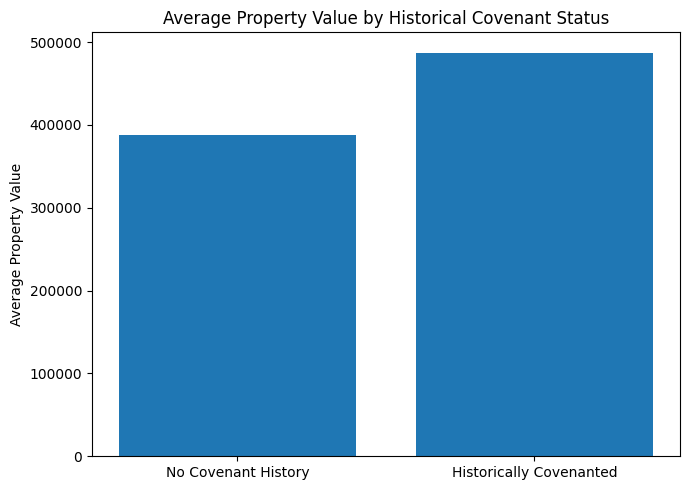

In [24]:
import matplotlib.pyplot as plt

avg_prop = df.groupby("historically_covenanted")["property_value"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["No Covenant History", "Historically Covenanted"], avg_prop.values)

plt.title("Average Property Value by Historical Covenant Status")
plt.ylabel("Average Property Value")

plt.tight_layout()
plt.show()

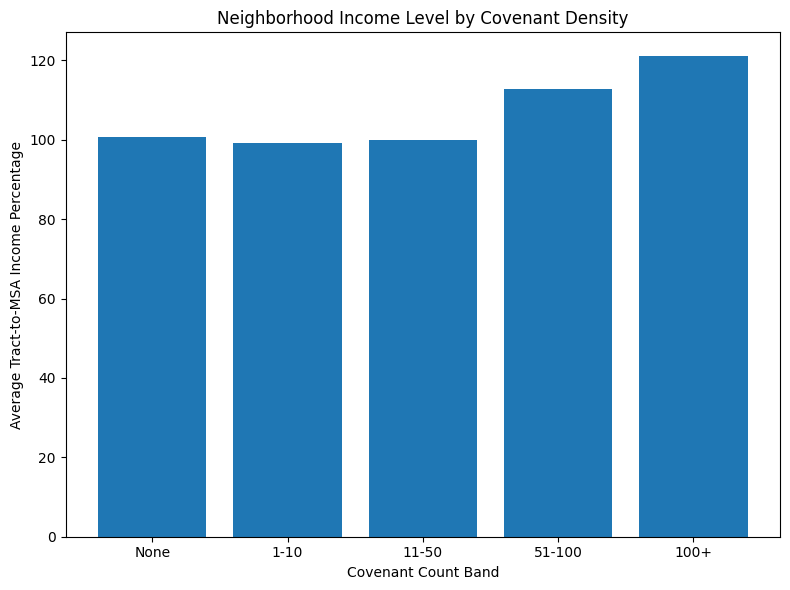

In [25]:
import matplotlib.pyplot as plt

band_order = ["None", "1-10", "11-50", "51-100", "100+"]
income_density = df.groupby("covenant_count_band")["tract_to_msa_income_percentage"].mean()
income_density = income_density.reindex(band_order)

plt.figure(figsize=(8, 6))
plt.bar(income_density.index, income_density.values)

plt.title("Neighborhood Income Level by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Tract-to-MSA Income Percentage")

plt.tight_layout()
plt.show()

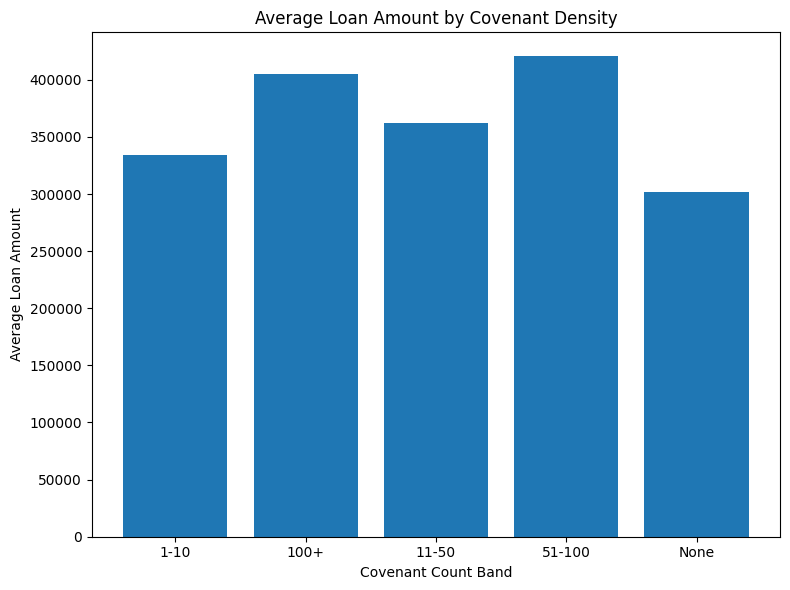

In [26]:
loan_by_covenant = df.groupby("covenant_count_band")["loan_amount"].mean()

plt.figure(figsize=(8,6))
plt.bar(loan_by_covenant.index, loan_by_covenant.values)

plt.title("Average Loan Amount by Covenant Density")
plt.xlabel("Covenant Count Band")
plt.ylabel("Average Loan Amount")

plt.tight_layout()
plt.show()